In [1]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:

# Load only specific columns
particles = load_dataset(
    "CERN/ColliderML-Release-1",
    "ttbar_pu0_calo_hits",
    split="train",
    
    streaming=True, 
)




Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

In [7]:
NUM_EVENTS = 1000
E_threshold = 0.0000

event_multiplicity = []

energies, x, y, z, detector = {}, {}, {}, {}, {}

for i, event in enumerate(tqdm(particles, total=NUM_EVENTS)):
    if i >= NUM_EVENTS:
        break

    mask = np.array(event["total_energy"]) > E_threshold
    event_multiplicity.append(len(np.array(event["x"])[mask]))
    energies[i] = np.array(event["total_energy"])[mask]
    x[i] = np.array(event["x"])[mask]
    y[i] = np.array(event["y"])[mask]
    z[i] = np.array(event["z"])[mask]
    detector[i] = np.array(event["detector"])[mask]

    

100%|██████████| 1000/1000 [04:59<00:00,  3.34it/s]


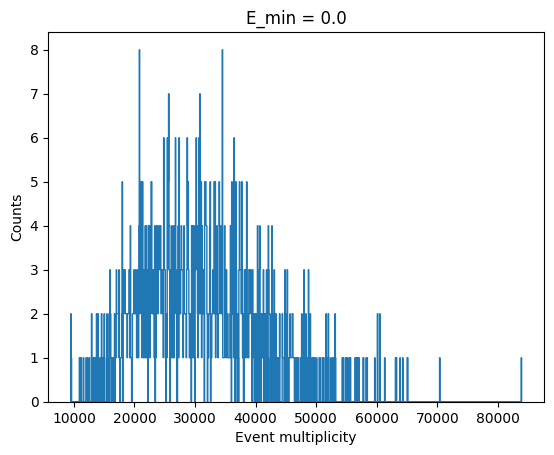

0


In [8]:
plt.figure()
plt.hist(event_multiplicity, histtype = "step", bins = 1000)
plt.xlabel("Event multiplicity")
plt.ylabel("Counts")
plt.title(f"E_min = {E_threshold}")
plt.show()


print(np.sum(np.array(event_multiplicity)==0))


In [ ]:
loc_x = np.array(x[0]) / 1e4
loc_y = np.array(y[0]) / 1e4
loc_z = np.array(z[0]) / 1e4
loc_e = np.log(np.array(energies[0]) * 1e2) / 10 

NUM_BINS = 100
BIN_BOUND = 0.75

plt.figure()
plt.hist(loc_x, bins = np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS), histtype = "step")
plt.xlabel("x (preprocessed)")
plt.ylabel("counts")
plt.yscale("log")
plt.show()

plt.figure()
plt.hist(loc_y, bins = np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS), histtype = "step")
plt.xlabel("y (preprocessed)")
plt.ylabel("counts")
plt.yscale("log")
plt.show()

plt.figure()
plt.hist(loc_z, bins = np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS), histtype = "step")
plt.xlabel("z (preprocessed)")
plt.ylabel("counts")
plt.yscale("log")
plt.show()

plt.figure()
plt.hist(loc_e, bins = np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS), histtype = "step")
plt.xlabel("e (preprocessed)")
plt.ylabel("counts")
plt.yscale("log")
plt.show()